C:\Users\hp\AppData\Local\Temp\ipykernel_5112\538400445.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\hp\AppData\Local\Temp\ipykernel_5112\538400445.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


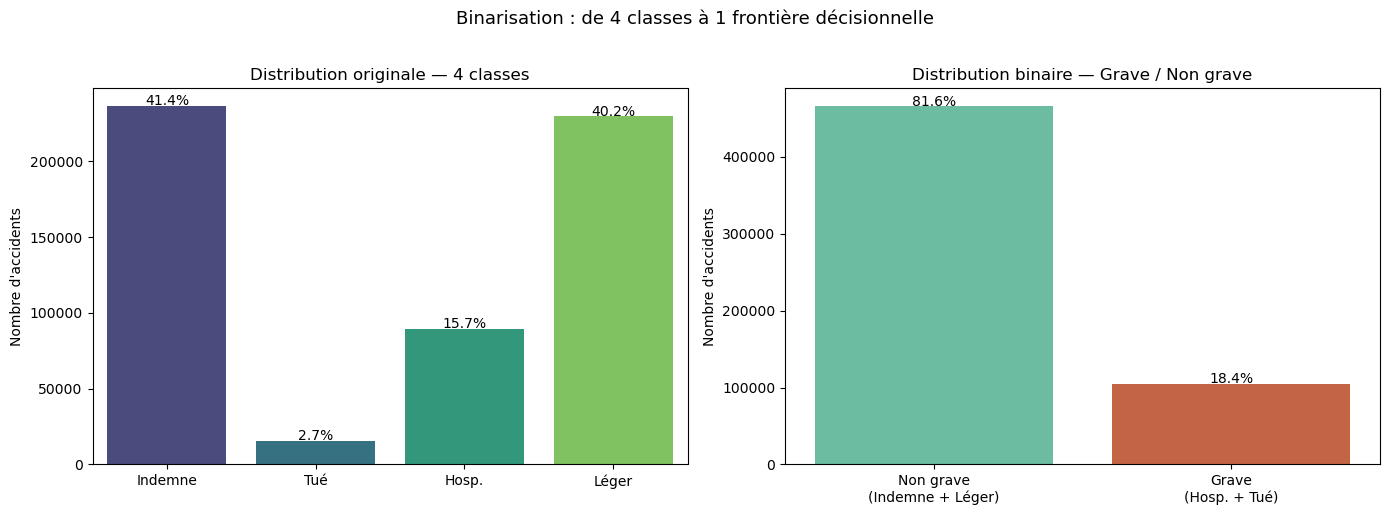

Déséquilibre binaire : 465,874 non graves / 105,098 graves
Ratio : 1 grave pour 4.4 non graves


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, roc_auc_score

# 1. CHARGEMENT DES DONNÉES
folder = r"C:\Users\hp\Documents\Formation Data Scientist\Projet - accidents\Data\Data encode 2 test"

x_train = pd.read_csv(folder + r"\X_train.csv")
x_test = pd.read_csv(folder + r"\X_test.csv")
y_train = pd.read_csv(folder + r"\y_train.csv")
y_test = pd.read_csv(folder + r"\y_test.csv")

# Remapping
mapping = {1.0: 0, 2.0: 1, 3.0: 2, 4.0: 3}
y_train_mapped = y_train.iloc[:, 0].map(mapping)
y_test_mapped = y_test.iloc[:, 0].map(mapping)

# 2. BINARISATION — sur train ET test séparément (pas de leakage)
def binariser(y):
    y = y.values.ravel()  # conversion en vecteur 1D
    return np.where(np.isin(y, [1, 4]), 0, 1)
    # 0 = non grave : Indemne (1) + Léger (4)
    # 1 = grave     : Hospitalisé (3) + Tué (2)

y_train_bin = binariser(y_train.iloc[:, 0])
y_test_bin = binariser(y_test.iloc[:, 0])

# 3. VISUALISATION COMPARÉE multi-classe vs binaire
noms_multi = {1: "Indemne", 2: "Tué", 3: "Hosp.", 4: "Léger"}
noms_binaire = {0: "Non grave\n(Indemne + Léger)", 1: "Grave\n(Hosp. + Tué)"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution originale
counts_multi = pd.Series(y_train.iloc[:, 0]).value_counts().sort_index()
sns.barplot(
    x=[noms_multi[int(i)] for i in counts_multi.index],
    y=counts_multi.values,
    palette="viridis",
    ax=axes[0]
)
axes[0].set_title("Distribution originale — 4 classes")
axes[0].set_ylabel("Nombre d'accidents")
for i, v in enumerate(counts_multi.values):
    axes[0].text(i, v + 500, f"{v/len(y_train)*100:.1f}%", ha='center', fontsize=10)

# Distribution binaire
counts_bin = pd.Series(y_train_bin).value_counts().sort_index()
sns.barplot(
    x=[noms_binaire[int(i)] for i in counts_bin.index],
    y=counts_bin.values,
    palette=["#5DCAA5", "#D85A30"],
    ax=axes[1]
)
axes[1].set_title("Distribution binaire — Grave / Non grave")
axes[1].set_ylabel("Nombre d'accidents")
for i, v in enumerate(counts_bin.values):
    axes[1].text(i, v + 500, f"{v/len(y_train_bin)*100:.1f}%", ha='center', fontsize=10)

plt.suptitle("Binarisation : de 4 classes à 1 frontière décisionnelle", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"Déséquilibre binaire : {counts_bin[0]:,} non graves / {counts_bin[1]:,} graves")
print(f"Ratio : 1 grave pour {counts_bin[0]/counts_bin[1]:.1f} non graves")



  Dummy (most_frequent)
  Accuracy        : 0.8168
  Macro F1        : 0.4496
  AUC-ROC         : 0.5000
  Recall 'grave'  : 0.0000

Classification Report :
              precision    recall  f1-score   support

   Non grave       0.82      1.00      0.90    116589
       Grave       0.00      0.00      0.00     26154

    accuracy                           0.82    142743
   macro avg       0.41      0.50      0.45    142743
weighted avg       0.67      0.82      0.73    142743



C:\Users\hp\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


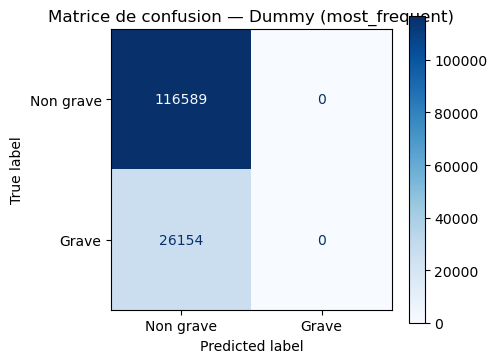

C:\Users\hp\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



  Régression logistique (balanced)
  Accuracy        : 0.7197
  Macro F1        : 0.6485
  AUC-ROC         : 0.8053
  Recall 'grave'  : 0.7364

Classification Report :
              precision    recall  f1-score   support

   Non grave       0.92      0.72      0.81    116589
       Grave       0.37      0.74      0.49     26154

    accuracy                           0.72    142743
   macro avg       0.65      0.73      0.65    142743
weighted avg       0.82      0.72      0.75    142743



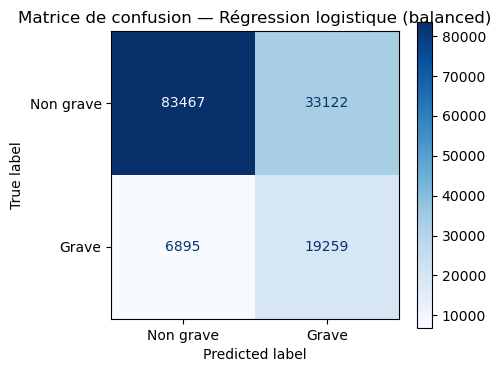


  Decision Tree (balanced)
  Accuracy        : 0.7281
  Macro F1        : 0.6654
  AUC-ROC         : 0.8402
  Recall 'grave'  : 0.8060

Classification Report :
              precision    recall  f1-score   support

   Non grave       0.94      0.71      0.81    116589
       Grave       0.38      0.81      0.52     26154

    accuracy                           0.73    142743
   macro avg       0.66      0.76      0.67    142743
weighted avg       0.84      0.73      0.76    142743



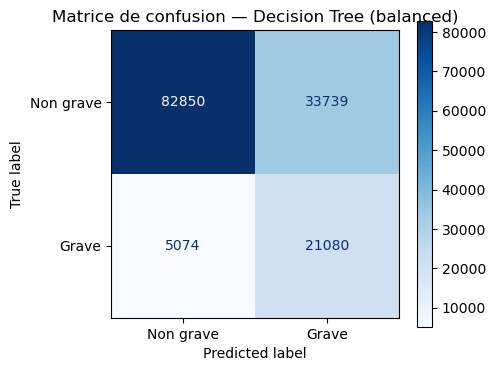


scale_pos_weight XGBoost : 4.43

  XGBoost pondéré
  Accuracy        : 0.7744
  Macro F1        : 0.7073
  AUC-ROC         : 0.8706
  Recall 'grave'  : 0.8061

Classification Report :
              precision    recall  f1-score   support

   Non grave       0.95      0.77      0.85    116589
       Grave       0.44      0.81      0.57     26154

    accuracy                           0.77    142743
   macro avg       0.69      0.79      0.71    142743
weighted avg       0.85      0.77      0.80    142743



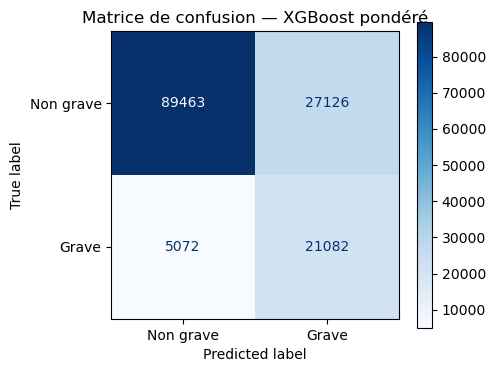


  Balanced Random Forest optimisé
  Accuracy        : 0.7506
  Macro F1        : 0.6899
  AUC-ROC         : 0.8692
  Recall 'grave'  : 0.8411

Classification Report :
              precision    recall  f1-score   support

   Non grave       0.95      0.73      0.83    116589
       Grave       0.41      0.84      0.55     26154

    accuracy                           0.75    142743
   macro avg       0.68      0.79      0.69    142743
weighted avg       0.85      0.75      0.78    142743



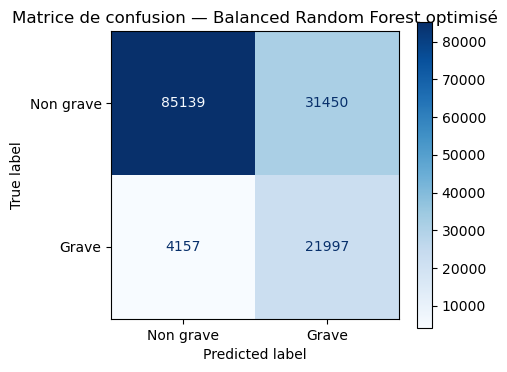


  SYNTHÈSE COMPARATIVE — Modèle binaire grave / non grave
                          Modèle  Accuracy  Macro F1    AUC  Recall grave
 Balanced Random Forest optimisé    0.7506    0.6899 0.8692        0.8411
                 XGBoost pondéré    0.7744    0.7073 0.8706        0.8061
        Decision Tree (balanced)    0.7281    0.6654 0.8402        0.8060
Régression logistique (balanced)    0.7197    0.6485 0.8053        0.7364
           Dummy (most_frequent)    0.8168    0.4496 0.5000        0.0000


C:\Users\hp\AppData\Local\Temp\ipykernel_5112\3277795534.py:155: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\hp\AppData\Local\Temp\ipykernel_5112\3277795534.py:155: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\hp\AppData\Local\Temp\ipykernel_5112\3277795534.py:155: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


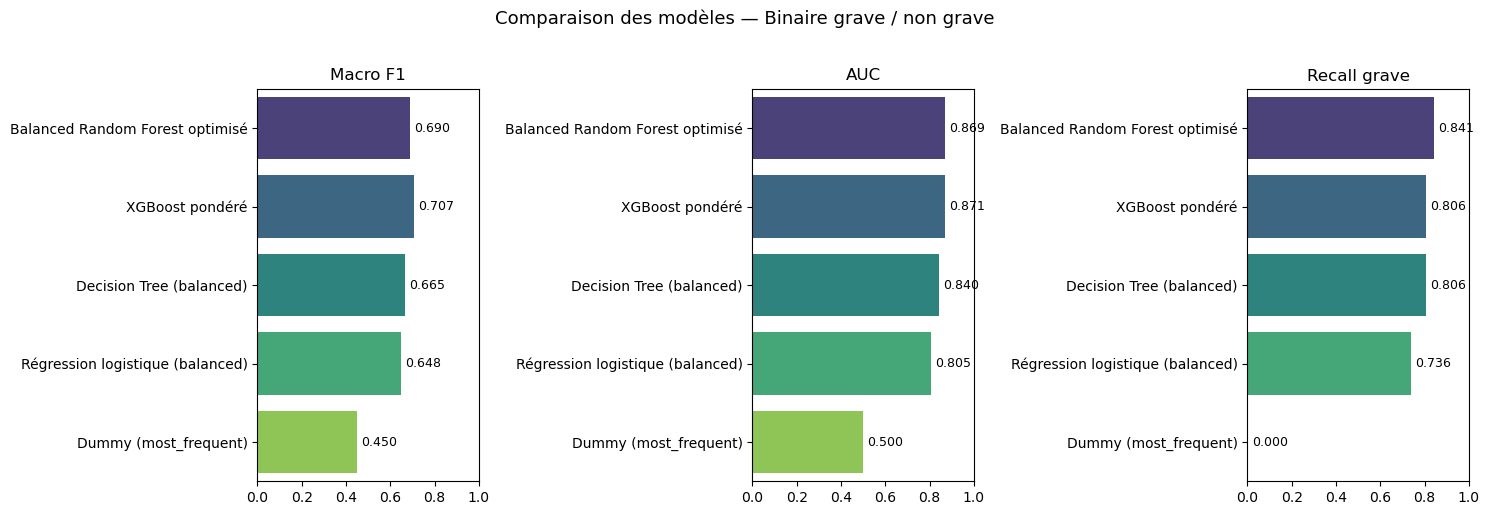

In [11]:
# !pip install xgboost
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, roc_auc_score,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# =============================================================
# FONCTION D'ÉVALUATION UNIQUE — appelée pour chaque modèle
# =============================================================

def evaluer(nom, modele, x_tr, y_tr, x_te, y_te):
    modele.fit(x_tr, y_tr)
    y_pred = modele.predict(x_te)
    y_proba = modele.predict_proba(x_te)[:, 1]

    acc = accuracy_score(y_te, y_pred)
    f1_macro = f1_score(y_te, y_pred, average="macro")
    auc = roc_auc_score(y_te, y_proba)
    recall_grave = classification_report(
        y_te, y_pred, output_dict=True
    )["1"]["recall"]

    print(f"\n{'='*55}")
    print(f"  {nom}")
    print(f"{'='*55}")
    print(f"  Accuracy        : {acc:.4f}")
    print(f"  Macro F1        : {f1_macro:.4f}")
    print(f"  AUC-ROC         : {auc:.4f}")
    print(f"  Recall 'grave'  : {recall_grave:.4f}")
    print("\nClassification Report :")
    print(classification_report(
        y_te, y_pred,
        target_names=["Non grave", "Grave"],
        zero_division=0
    ))

    # Matrice de confusion
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(
        y_te, y_pred,
        display_labels=["Non grave", "Grave"],
        cmap="Blues", ax=ax
    )
    ax.set_title(f"Matrice de confusion — {nom}")
    plt.tight_layout()
    plt.show()

    return {
        "Modèle": nom,
        "Accuracy": round(acc, 4),
        "Macro F1": round(f1_macro, 4),
        "AUC": round(auc, 4),
        "Recall grave": round(recall_grave, 4)
    }

# =============================================================
# 1. DUMMY — plancher de référence
# =============================================================

r1 = evaluer(
    "Dummy (most_frequent)",
    DummyClassifier(strategy="most_frequent"),
    x_train, y_train_bin, x_test, y_test_bin
)

# =============================================================
# 2. RÉGRESSION LOGISTIQUE
# =============================================================

r2 = evaluer(
    "Régression logistique (balanced)",
    LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42),
    x_train, y_train_bin, x_test, y_test_bin
)

# =============================================================
# 3. DECISION TREE
# =============================================================

r3 = evaluer(
    "Decision Tree (balanced)",
    DecisionTreeClassifier(class_weight="balanced", max_depth=10, random_state=42),
    x_train, y_train_bin, x_test, y_test_bin
)

# =============================================================
# 4. XGBOOST — poids calculé automatiquement
# =============================================================

n_neg = (y_train_bin == 0).sum()
n_pos = (y_train_bin == 1).sum()
scale = n_neg / n_pos
print(f"\nscale_pos_weight XGBoost : {scale:.2f}")

r4 = evaluer(
    "XGBoost pondéré",
    XGBClassifier(
        n_estimators=300,
        max_depth=8,
        learning_rate=0.1,
        subsample=1.0,
        colsample_bytree=0.7,
        min_child_weight=5,
        scale_pos_weight=scale,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ),
    x_train, y_train_bin, x_test, y_test_bin
)

# =============================================================
# 5. BALANCED RANDOM FOREST — modèle recommandé
# =============================================================

r5 = evaluer(
    "Balanced Random Forest optimisé",
    BalancedRandomForestClassifier(
        n_estimators=300,
        max_depth=20,
        min_samples_split=2,
        sampling_strategy="not minority",
        random_state=42,
        n_jobs=-1
    ),
    x_train, y_train_bin, x_test, y_test_bin
)

# =============================================================
# 6. TABLEAU DE SYNTHÈSE COMPARATIF
# =============================================================

synthese = pd.DataFrame([r1, r2, r3, r4, r5])
synthese = synthese.sort_values("Recall grave", ascending=False)

print("\n" + "="*60)
print("  SYNTHÈSE COMPARATIVE — Modèle binaire grave / non grave")
print("="*60)
print(synthese.to_string(index=False))

# Visualisation synthèse
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metriques = ["Macro F1", "AUC", "Recall grave"]

for ax, metrique in zip(axes, metriques):
    sns.barplot(
        data=synthese, x=metrique, y="Modèle",
        palette="viridis", ax=ax
    )
    ax.set_xlim(0, 1)
    ax.set_title(metrique)
    ax.set_xlabel("")
    ax.set_ylabel("")
    for container in ax.containers:
        ax.bar_label(container, fmt="%.3f", padding=3, fontsize=9)

plt.suptitle("Comparaison des modèles — Binaire grave / non grave", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()



  Balanced Random Forest optimisé
  Accuracy        : 0.7506
  Macro F1        : 0.6899
  AUC-ROC         : 0.8692
  Recall 'grave'  : 0.8411

Classification Report :
              precision    recall  f1-score   support

   Non grave       0.95      0.73      0.83    116589
       Grave       0.41      0.84      0.55     26154

    accuracy                           0.75    142743
   macro avg       0.68      0.79      0.69    142743
weighted avg       0.85      0.75      0.78    142743



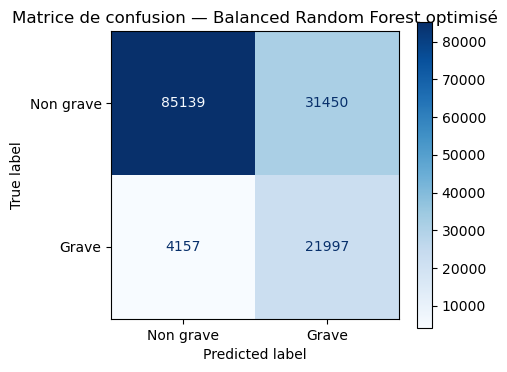


  SYNTHÈSE COMPARATIVE — Modèle binaire grave / non grave
                         Modèle  Accuracy  Macro F1    AUC  Recall grave
Balanced Random Forest optimisé    0.7506    0.6899 0.8692        0.8411


C:\Users\hp\AppData\Local\Temp\ipykernel_5112\2943919155.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\hp\AppData\Local\Temp\ipykernel_5112\2943919155.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\hp\AppData\Local\Temp\ipykernel_5112\2943919155.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


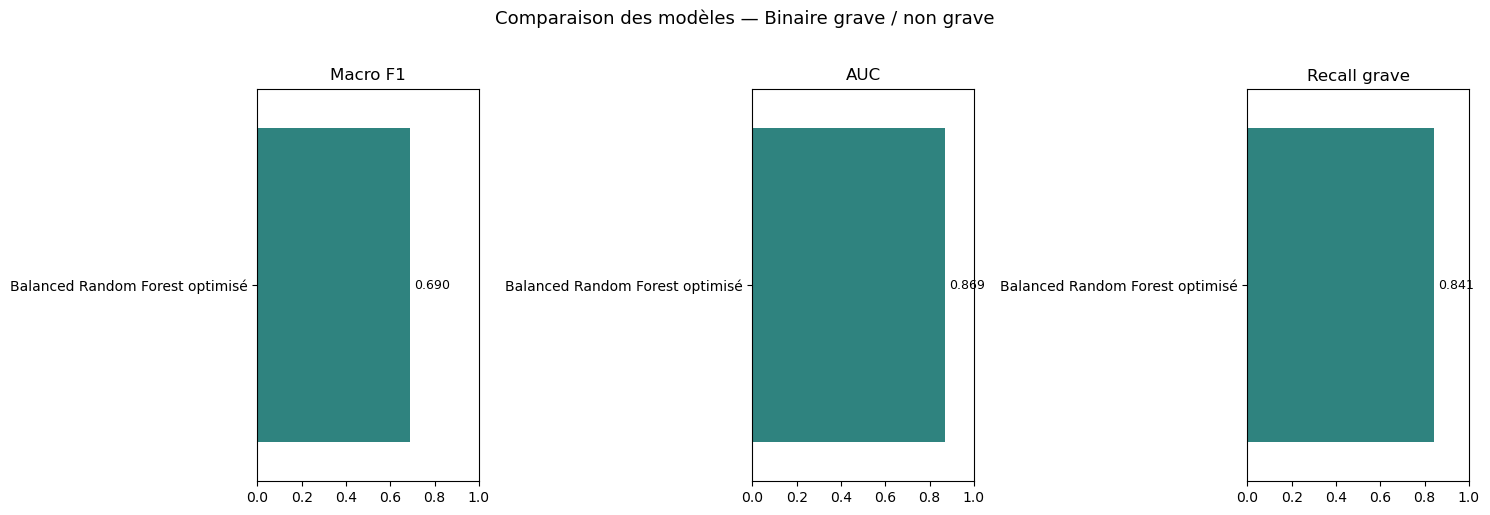

In [16]:
# =============================================================
# 6. BALANCED RANDOM FOREST avec modification importance poids grave — modèle recommandé
# =============================================================

r6 = evaluer(
    "Balanced Random Forest optimisé",
    BalancedRandomForestClassifier(
        n_estimators=300,
        max_depth=20,
        min_samples_split=2,
        sampling_strategy= 1.0,
        random_state=42,
        n_jobs=-1
    ),
    x_train, y_train_bin, x_test, y_test_bin
)

# -----------------------------
# Évaluation
# -----------------------------
synthese = pd.DataFrame([r6])
synthese = synthese.sort_values("Recall grave", ascending=False)

print("\n" + "="*60)
print("  SYNTHÈSE COMPARATIVE — Modèle binaire grave / non grave")
print("="*60)
print(synthese.to_string(index=False))

# Visualisation synthèse
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metriques = ["Macro F1", "AUC", "Recall grave"]

for ax, metrique in zip(axes, metriques):
    sns.barplot(
        data=synthese, x=metrique, y="Modèle",
        palette="viridis", ax=ax
    )
    ax.set_xlim(0, 1)
    ax.set_title(metrique)
    ax.set_xlabel("")
    ax.set_ylabel("")
    for container in ax.containers:
        ax.bar_label(container, fmt="%.3f", padding=3, fontsize=9)

plt.suptitle("Comparaison des modèles — Binaire grave / non grave", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, precision_recall_curve
)

from imblearn.ensemble import BalancedRandomForestClassifier


# =============================================================
# 1. FONCTION D'ÉVALUATION — retourne métriques + modèle entraîné
# =============================================================

def evaluer(nom, modele, x_tr, y_tr, x_te, y_te):
    modele.fit(x_tr, y_tr)
    y_pred = modele.predict(x_te)
    y_proba = modele.predict_proba(x_te)[:, 1]

    acc = accuracy_score(y_te, y_pred)
    f1_macro = f1_score(y_te, y_pred, average="macro")
    auc = roc_auc_score(y_te, y_proba)
    recall_grave = classification_report(
        y_te, y_pred, output_dict=True
    )["1"]["recall"]

    resultats = {
        "Modèle": nom,
        "Accuracy": round(acc, 4),
        "Macro F1": round(f1_macro, 4),
        "AUC": round(auc, 4),
        "Recall grave": round(recall_grave, 4)
    }

    return resultats, modele


# =============================================================
# 2. ENTRAÎNEMENT DU BALANCED RANDOM FOREST
# =============================================================

r5, modele_r5 = evaluer(
    "Balanced Random Forest optimisé",
    BalancedRandomForestClassifier(
        n_estimators=300,
        max_depth=20,
        min_samples_split=2,
        sampling_strategy=1.0,   # équilibre parfait
        random_state=42,
        n_jobs=-1
    ),
    x_train, y_train_bin, x_test, y_test_bin
)

print("\n=== Résultats du modèle avant optimisation du seuil ===")
print(r5)


# =============================================================
# 3. OPTIMISATION DU SEUIL DE DÉCISION
# =============================================================

# Probabilités prédites
y_proba = modele_r5.predict_proba(x_test)[:, 1]

# Courbe précision–recall
precisions, recalls, thresholds = precision_recall_curve(y_test_bin, y_proba)

# Recall minimum à conserver (recall actuel)
recall_min = r5["Recall grave"]

best_threshold = 0.5
best_precision = 0
best_recall = 0

for p, r, t in zip(precisions, recalls, np.append(thresholds, 1)):
    if r >= recall_min and p > best_precision:
        best_precision = p
        best_recall = r
        best_threshold = t


print("\n==============================")
print("  OPTIMISATION DU SEUIL")
print("==============================")
print(f"Seuil optimal : {best_threshold:.3f}")
print(f"Precision grave optimisée : {best_precision:.3f}")
print(f"Recall grave conservé     : {best_recall:.3f}")


# =============================================================
# 4. ÉVALUATION AVEC SEUIL OPTIMISÉ
# =============================================================

y_pred_opt = (y_proba >= best_threshold).astype(int)

print("\n=== Classification report avec seuil optimisé ===")
print(classification_report(
    y_test_bin, y_pred_opt,
    target_names=["Non grave", "Grave"],
    zero_division=0
))



=== Résultats du modèle avant optimisation du seuil ===
{'Modèle': 'Balanced Random Forest optimisé', 'Accuracy': 0.7506, 'Macro F1': 0.6899, 'AUC': 0.8692, 'Recall grave': 0.8411}

  OPTIMISATION DU SEUIL
Seuil optimal : 0.500
Precision grave optimisée : 0.412
Recall grave conservé     : 0.841

=== Classification report avec seuil optimisé ===
              precision    recall  f1-score   support

   Non grave       0.95      0.73      0.83    116589
       Grave       0.41      0.84      0.55     26154

    accuracy                           0.75    142743
   macro avg       0.68      0.79      0.69    142743
weighted avg       0.85      0.75      0.78    142743



In [21]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

# =============================================================
# Pipeline SMOTE + RandomForest
# =============================================================

pipeline = Pipeline([
    ("smote", SMOTE(sampling_strategy=0.8, random_state=42)),
    ("rf", RandomForestClassifier(
        n_estimators=300,
        max_depth=20,
        random_state=42,
        n_jobs=-1
    ))
])

# =============================================================
# Grille de recherche des poids
# =============================================================

param_grid = {
    "rf__class_weight": [
        {0: 1, 1: 1},
        {0: 1, 1: 2},
        {0: 1, 1: 3},
        {0: 1, 1: 5},
        {0: 1, 1: 10}
    ]
}

# =============================================================
# Grid Search
# =============================================================

grid = GridSearchCV(
    pipeline,
    param_grid,
    scoring="recall",   # maximise le recall grave
    cv=3,
    n_jobs=-1,
    verbose=2
)

grid.fit(x_train, y_train_bin)

print("\nMeilleurs paramètres trouvés :")
print(grid.best_params_)

# =============================================================
# Évaluation finale
# =============================================================

best_model = grid.best_estimator_
y_pred = best_model.predict(x_test)

print("\n=== Rapport final ===")
print(classification_report(
    y_test_bin, y_pred,
    target_names=["Non grave", "Grave"],
    zero_division=0
))


Fitting 3 folds for each of 5 candidates, totalling 15 fits

Meilleurs paramètres trouvés :
{'rf__class_weight': {0: 1, 1: 10}}

=== Rapport final ===
              precision    recall  f1-score   support

   Non grave       0.95      0.67      0.79    116589
       Grave       0.37      0.86      0.52     26154

    accuracy                           0.70    142743
   macro avg       0.66      0.76      0.65    142743
weighted avg       0.85      0.70      0.74    142743



In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report
)
from sklearn.model_selection import train_test_split, GridSearchCV

from imblearn.ensemble import BalancedRandomForestClassifier
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier


# =============================================================
# 1. CHARGEMENT DU DATAFRAME D’ORIGINE
# =============================================================

folder = r"C:\Users\hp\Documents\Formation Data Scientist\Projet - accidents\Data\Data encode 2 test"
file = folder + r"\accidents_France_encoded.csv"

df = pd.read_csv(file)

# =============================================================
# 2. CRÉATION DE LA CIBLE BINAIRE : GRAVE / NON GRAVE
# =============================================================

# 2 = tué, 3 = hospitalisé → grave
df["y_bin"] = df["gravite"].apply(lambda x: 1 if x in [2, 3] else 0)

# Séparation X / y
X = df.drop(columns=["gravite", "y_bin"])
y = df["y_bin"]

x_train, x_test, y_train_bin, y_test_bin = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


# =============================================================
# 3. FONCTION D'ÉVALUATION
# =============================================================

def evaluer(nom, modele, x_tr, y_tr, x_te, y_te):
    modele.fit(x_tr, y_tr)
    y_pred = modele.predict(x_te)
    y_proba = modele.predict_proba(x_te)[:, 1]

    acc = accuracy_score(y_te, y_pred)
    f1_macro = f1_score(y_te, y_pred, average="macro")
    auc = roc_auc_score(y_te, y_proba)
    recall_grave = classification_report(
        y_te, y_pred, output_dict=True
    )["1"]["recall"]

    resultats = {
        "Modèle": nom,
        "Accuracy": round(acc, 4),
        "Macro F1": round(f1_macro, 4),
        "AUC": round(auc, 4),
        "Recall grave": round(recall_grave, 4)
    }

    return resultats, modele


# =============================================================
# 4. MODÈLE BINAIRE r6 — Balanced Random Forest optimisé
# =============================================================

r6, modele_r6 = evaluer(
    "Balanced Random Forest optimisé",
    BalancedRandomForestClassifier(
        n_estimators=300,
        max_depth=20,
        min_samples_split=2,
        sampling_strategy=1.0,
        random_state=42,
        n_jobs=-1
    ),
    x_train, y_train_bin, x_test, y_test_bin
)

# Synthèse
synthese = pd.DataFrame([r6]).sort_values("Recall grave", ascending=False)

print("\n" + "="*60)
print("  SYNTHÈSE — Modèle binaire grave / non grave")
print("="*60)
print(synthese.to_string(index=False))


# =============================================================
# 5. PAS D’OPTIMISATION DE SEUIL — seuil = 0.50
# =============================================================

print("\nSeuil utilisé pour la classification grave / non grave : 0.50\n")


# =============================================================
# 6. MODÈLE 2 — HOSPITALISÉ (3) vs TUÉ (2)
# =============================================================

# Filtrer uniquement les cas graves RÉELS
df_graves = df[df["y_bin"] == 1].copy()

# Nouvelle cible : hospitalisé vs tué
df_graves["y_grave"] = df_graves["gravite"].map({
    3: 0,   # Hospitalisé
    2: 1    # Tué
})

Xg = df_graves.drop(columns=["gravite", "y_bin", "y_grave"])
yg = df_graves["y_grave"]

xg_train, xg_test, yg_train, yg_test = train_test_split(
    Xg, yg, test_size=0.2, random_state=42, stratify=yg
)

# Pipeline SMOTE + RandomForest
pipeline_grave = Pipeline([
    ("smote", SMOTE(sampling_strategy=0.8, random_state=42)),
    ("rf", RandomForestClassifier(
        n_estimators=300,
        max_depth=20,
        random_state=42,
        n_jobs=-1
    ))
])

# Grille de recherche des poids
param_grid = {
    "rf__class_weight": [
        {0: 1, 1: 1},
        {0: 1, 1: 2},
        {0: 1, 1: 3},
        {0: 1, 1: 5},
        {0: 1, 1: 10}
    ]
}

grid = GridSearchCV(
    pipeline_grave,
    param_grid,
    scoring="recall",
    cv=3,
    n_jobs=-1,
    verbose=2
)

grid.fit(xg_train, yg_train)

print("\n=== Meilleurs paramètres pour hospitalisé vs tué ===")
print(grid.best_params_)

best_model_grave = grid.best_estimator_
y_pred_grave = best_model_grave.predict(xg_test)

print("\n=== Classification hospitalisé vs tué ===")
print(classification_report(
    yg_test, y_pred_grave,
    target_names=["Hospitalisé", "Tué"],
    zero_division=0
))



  SYNTHÈSE — Modèle binaire grave / non grave
                         Modèle  Accuracy  Macro F1    AUC  Recall grave
Balanced Random Forest optimisé    0.7525    0.6917 0.8693        0.8391

Seuil utilisé pour la classification grave / non grave : 0.50

Fitting 3 folds for each of 5 candidates, totalling 15 fits

=== Meilleurs paramètres pour hospitalisé vs tué ===
{'rf__class_weight': {0: 1, 1: 10}}

=== Classification hospitalisé vs tué ===
              precision    recall  f1-score   support

 Hospitalisé       0.90      0.71      0.79     22359
         Tué       0.25      0.56      0.35      3892

    accuracy                           0.69     26251
   macro avg       0.58      0.63      0.57     26251
weighted avg       0.81      0.69      0.73     26251



In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report
)

from imblearn.ensemble import BalancedRandomForestClassifier
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier


# =============================================================
# 1. CHARGEMENT DES DONNÉES
# =============================================================

folder = r"C:\Users\hp\Documents\Formation Data Scientist\Projet - accidents\Data\Data encode 2 test"

x_train = pd.read_csv(folder + r"\X_train.csv")
x_test = pd.read_csv(folder + r"\X_test.csv")
y_train = pd.read_csv(folder + r"\y_train.csv")
y_test = pd.read_csv(folder + r"\y_test.csv")


# =============================================================
# 2. NETTOYAGE 
# =============================================================

def nettoyer_cible(y):
    col = y.iloc[:,0]
    col = col.astype(str).str.strip().replace("", np.nan)
    col = col.astype(float).astype("Int64")
    return col

y_train_clean = nettoyer_cible(y_train)
y_test_clean  = nettoyer_cible(y_test)

mapping = {1:0, 2:1, 3:2, 4:3}
y_train_mapped = y_train_clean.map(mapping)
y_test_mapped  = y_test_clean.map(mapping)


# =============================================================
# 3. BINARISATION 
# =============================================================

def binariser(y):
    y = y.values.ravel()
    return np.where(np.isin(y, [1, 4]), 0, 1)

y_train_bin = binariser(y_train_clean)
y_test_bin  = binariser(y_test_clean)


# =============================================================
# 4. ALIGNEMENT DES INDEX
# =============================================================

y_train_mapped.index = x_train.index
y_test_mapped.index  = x_test.index
y_train_clean.index  = x_train.index
y_test_clean.index   = x_test.index


# =============================================================
# 5. FONCTION D'ÉVALUATION
# =============================================================

def evaluer(nom, modele, x_tr, y_tr, x_te, y_te):
    modele.fit(x_tr, y_tr)
    y_pred = modele.predict(x_te)
    y_proba = modele.predict_proba(x_te)[:, 1]

    acc = accuracy_score(y_te, y_pred)
    f1_macro = f1_score(y_te, y_pred, average="macro")
    auc = roc_auc_score(y_te, y_proba)
    recall_grave = classification_report(
        y_te, y_pred, output_dict=True
    )["1"]["recall"]

    return {
        "Modèle": nom,
        "Accuracy": round(acc, 4),
        "Macro F1": round(f1_macro, 4),
        "AUC": round(auc, 4),
        "Recall grave": round(recall_grave, 4)
    }, modele


# =============================================================
# 6. MODÈLE BINAIRE r6 — Balanced Random Forest
# =============================================================

r6, modele_r6 = evaluer(
    "Balanced Random Forest optimisé",
    BalancedRandomForestClassifier(
        n_estimators=300,
        max_depth=20,
        min_samples_split=2,
        sampling_strategy=1.0,
        random_state=42,
        n_jobs=-1
    ),
    x_train, y_train_bin, x_test, y_test_bin
)

print("\n=== SYNTHÈSE — Modèle grave / non grave ===")
print(pd.DataFrame([r6]).to_string(index=False))


# =============================================================
# 7. MODÈLE HOSPITALISÉ (3) vs TUÉ (2)
# =============================================================

# Filtrer uniquement les vraies valeurs 2 et 3
mask_train_graves = y_train_clean.isin([2,3])
mask_test_graves  = y_test_clean.isin([2,3])

train_graves = x_train.loc[mask_train_graves]
test_graves  = x_test.loc[mask_test_graves]

y_train_graves = y_train_clean.loc[mask_train_graves].map({2:1, 3:0})
y_test_graves  = y_test_clean.loc[mask_test_graves].map({2:1, 3:0})

print("\nNaN dans y_train_graves :", y_train_graves.isna().sum())
print("NaN dans y_test_graves  :", y_test_graves.isna().sum())


# Pipeline final
pipeline_grave = Pipeline([
    ("smote", SMOTE(sampling_strategy=0.8, random_state=42)),
    ("rf", RandomForestClassifier(
        n_estimators=300,
        max_depth=20,
        class_weight={0:1, 1:10},
        random_state=42,
        n_jobs=-1
    ))
])

pipeline_grave.fit(train_graves, y_train_graves)

y_pred_grave = pipeline_grave.predict(test_graves)

print("\n=== Classification hospitalisé vs tué ===")
print(classification_report(
    y_test_graves, y_pred_grave,
    target_names=["Hospitalisé", "Tué"],
    zero_division=0
))



=== SYNTHÈSE — Modèle grave / non grave ===
                         Modèle  Accuracy  Macro F1    AUC  Recall grave
Balanced Random Forest optimisé    0.7506    0.6899 0.8692        0.8411

NaN dans y_train_graves : 0
NaN dans y_test_graves  : 0

=== Classification hospitalisé vs tué ===
              precision    recall  f1-score   support

 Hospitalisé       0.90      0.70      0.79     22287
         Tué       0.25      0.56      0.34      3867

    accuracy                           0.68     26154
   macro avg       0.57      0.63      0.57     26154
weighted avg       0.81      0.68      0.72     26154



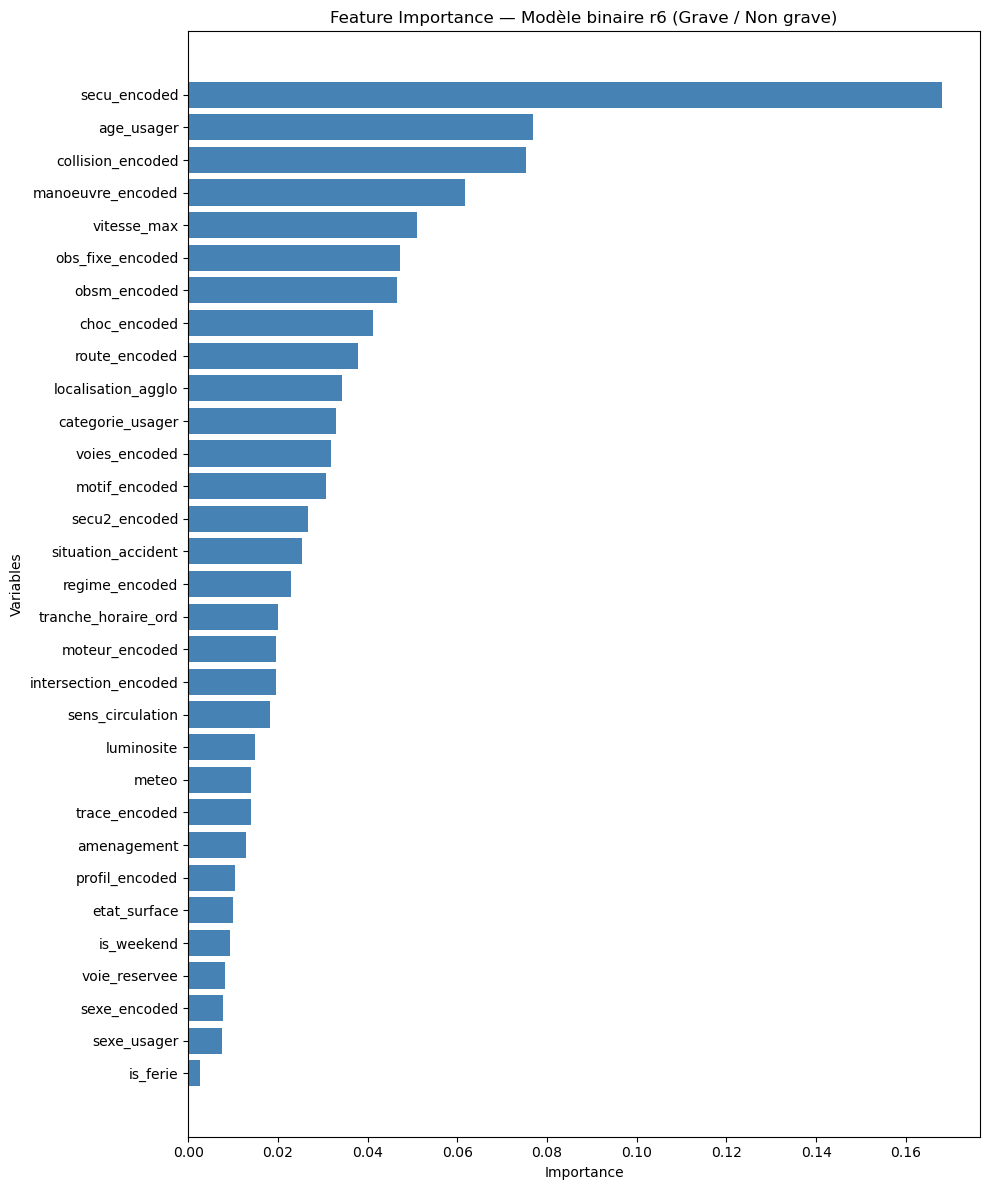


=== Feature Importance — Modèle binaire r6 ===
             feature  importance
        secu_encoded    0.168106
          age_usager    0.076770
   collision_encoded    0.075394
   manoeuvre_encoded    0.061806
         vitesse_max    0.050914
    obs_fixe_encoded    0.047257
        obsm_encoded    0.046651
        choc_encoded    0.041175
       route_encoded    0.037892
  localisation_agglo    0.034384
    categorie_usager    0.033025
       voies_encoded    0.031784
       motif_encoded    0.030743
       secu2_encoded    0.026620
  situation_accident    0.025430
      regime_encoded    0.022844
 tranche_horaire_ord    0.020086
      moteur_encoded    0.019659
intersection_encoded    0.019500
    sens_circulation    0.018322
          luminosite    0.014893
               meteo    0.014031
       trace_encoded    0.014005
         amenagement    0.012906
      profil_encoded    0.010435
        etat_surface    0.009897
          is_weekend    0.009248
       voie_reservee    0.00

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Importance des features du modèle binaire r6
importances_r6 = modele_r6.feature_importances_
features = x_train.columns

fi_r6 = pd.DataFrame({
    "feature": features,
    "importance": importances_r6
}).sort_values("importance", ascending=False)

# --- Histogramme ---
plt.figure(figsize=(10, 12))
plt.barh(fi_r6["feature"], fi_r6["importance"], color="steelblue")
plt.gca().invert_yaxis()
plt.title("Feature Importance — Modèle binaire r6 (Grave / Non grave)")
plt.xlabel("Importance")
plt.ylabel("Variables")
plt.tight_layout()
plt.show()

# --- Listing propre ---
print("\n=== Feature Importance — Modèle binaire r6 ===")
print(fi_r6.to_string(index=False))


In [2]:
def predict_gravite(df):
    """
    df : DataFrame contenant les mêmes colonnes que X_train
    Retourne : gravité binaire + gravité détaillée si grave
    """

    # 1. Prédiction grave / non grave
    proba_grave = modele_r6.predict_proba(df)[:, 1]
    pred_grave = (proba_grave >= 0.5).astype(int)

    # 2. Initialisation du résultat
    resultats = []

    for i, is_grave in enumerate(pred_grave):

        if is_grave == 0:
            resultats.append({
                "gravite_binaire": "Non grave",
                "gravite_detaillee": "Indemne ou Léger"
            })

        else:
            # 3. Prédiction hospitalisé / tué
            ligne = df.iloc[[i]]  # garder DataFrame
            pred_ht = pipeline_grave.predict(ligne)[0]

            if pred_ht == 0:
                detail = "Hospitalisé"
            else:
                detail = "Tué"

            resultats.append({
                "gravite_binaire": "Grave",
                "gravite_detaillee": detail
            })

    return pd.DataFrame(resultats)


In [5]:
import pandas as pd

folder = r"C:\Users\hp\Documents\Formation Data Scientist\Projet - accidents\Data\Data encode 2 test"
X_train = pd.read_csv(folder + r"\X_train.csv")


nouvel_accident = pd.DataFrame([{
    "secu_encoded": 2.772388,
    "age_usager": 18,
    "collision_encoded": 2.46,
    "manoeuvre_encoded": 2.66,
    "vitesse_max": 50,
    "obs_fixe_encoded": 2.46,
    "obsm_encoded": 2.48,
    "choc_encoded": 2.71,
    "route_encoded": 2.56,
    "localisation_agglo": 1,
    "categorie_usager": 1,
    "voies_encoded": 2.55,
    "motif_encoded": 2.59,
    "secu2_encoded": 2.46,
    "situation_accident": 1.0,
    "regime_encoded": 2.55,
    "tranche_horaire_ord": 2,
    "moteur_encoded": 2.48,
    "intersection_encoded": 2.57,
    "sens_circulation": 1.0,
    "luminosite": 1.0,
    "meteo": 1.0,
    "trace_encoded": 2.52,
    "amenagement": 0.0,
    "profil_encoded": 2.53,
    "etat_surface": 1.0,
    "is_weekend": 0,
    "voie_reservee": 0.0,
    "sexe_encoded": 0,
    "sexe_usager": 1.0,
    "is_ferie": 0
}])

# Réordonner selon X_train
nouvel_accident = nouvel_accident[X_train.columns]

predict_gravite(nouvel_accident)

,gravite_binaire,gravite_detaillee
0,Grave,Tué


In [6]:
import pandas as pd
folder = r"C:\Users\hp\Documents\Formation Data Scientist\Projet - accidents\Data\Data encode 2 test"
df = pd.read_csv(folder + r"\X_train.csv")

df.head()

for col in df.columns:
    print(f"\n=== {col} ===")
    print(df[col].value_counts())


=== luminosite ===
luminosite
1.0    381932
5.0     86867
3.0     60004
2.0     36717
4.0      5452
Name: count, dtype: int64

=== localisation_agglo ===
localisation_agglo
2    346962
1    224010
Name: count, dtype: int64

=== meteo ===
meteo
1.0    451793
2.0     63316
8.0     21760
3.0     13453
7.0     10240
5.0      4095
9.0      2518
4.0      2180
6.0      1617
Name: count, dtype: int64

=== voie_reservee ===
voie_reservee
0.0    512705
1.0     24663
3.0     19114
2.0     14490
Name: count, dtype: int64

=== etat_surface ===
etat_surface
1.0    457525
2.0    105647
9.0      2459
7.0      2150
5.0       991
3.0       896
8.0       702
6.0       329
4.0       273
Name: count, dtype: int64

=== amenagement ===
amenagement
0.0    482492
5.0     31778
9.0     19352
2.0     10514
3.0      7704
1.0      7643
6.0      4984
8.0      4266
4.0      1824
7.0       415
Name: count, dtype: int64

=== situation_accident ===
situation_accident
1.0    497159
3.0     31005
8.0     15077
4.0      

In [7]:
import os 
print(os.getcwd())

C:\Users\hp
